## Исследовательский анализ данных EDA

In [62]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

import numpy as np 
from datetime import datetime
from matplotlib import pyplot as plt 
import seaborn as sns 

from scipy import stats 


In [63]:
# Загружаем переменные из файла .env 
load_dotenv() 
# Получаем адрес подключения к БД 
database_url = os.getenv("DATABASE_URL") 
    
# Создаём подключение к БД 
engine = create_engine(database_url) 

# Проверяем подключение 
with engine.connect(): 
    print("Подключение к БД успешно") 
    
# Выполняем SQL-запрос и получаем DataFrame 
query = '''
        SELECT *
        FROM clean_banks_data
    '''
df = pd.read_sql(query, engine)
display(df.head())

Подключение к БД успешно


,children,days_employed,client_age,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose,years_employed,purpose_group
0,1,8437,42,высшее,0,женат / замужем,0,жен,сотрудник,0,253875,покупка жилья,23.116912,недвижимость
1,1,4024,36,среднее,1,женат / замужем,0,жен,сотрудник,0,112080,приобретение автомобиля,11.026860,автомобиль
2,0,5623,33,среднее,1,женат / замужем,0,муж,сотрудник,0,145885,покупка жилья,15.406637,недвижимость
3,3,4124,32,среднее,1,женат / замужем,0,муж,сотрудник,0,267628,дополнительное образование,11.300677,образование
4,0,340266,53,среднее,1,гражданский брак,1,жен,пенсионер,0,158616,сыграть свадьбу,NaN,свадьба


## Проверка корреляции признаков с наличием дефолта

In [64]:
df['debt'].value_counts()

debt
0    17586
1     1552
Name: count, dtype: int64

In [65]:
# кодируем категориальные переменные
df_encoded = pd.get_dummies(
    df, 
    columns=['gender', 'purpose_group', 'income_type'] 
  
)

In [66]:
df_encoded = df_encoded.drop(columns=['education', 'family_status', 'purpose', 'days_employed'])
df_encoded.head()

,children,client_age,education_id,family_status_id,debt,total_income,years_employed,gender_жен,gender_муж,purpose_group_автомобиль,purpose_group_недвижимость,purpose_group_образование,purpose_group_свадьба,income_type_госслужащий,income_type_компаньон,income_type_пенсионер,income_type_сотрудник
0,1,42,0,0,0,253875,23.116912,True,False,False,True,False,False,False,False,False,True
1,1,36,1,0,0,112080,11.026860,True,False,True,False,False,False,False,False,False,True
2,0,33,1,0,0,145885,15.406637,False,True,False,True,False,False,False,False,False,True
3,3,32,1,0,0,267628,11.300677,False,True,False,False,True,False,False,False,False,True
4,0,53,1,1,0,158616,NaN,True,False,False,False,False,True,False,False,True,False


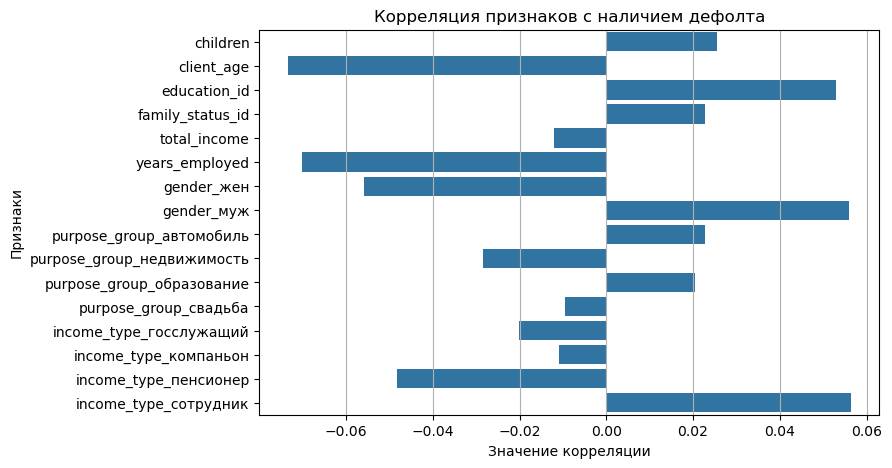

In [67]:
# корреляция столбца debt в виде отдельного графика
corr_matrix = df_encoded.corr()
debt_corr = corr_matrix['debt'].drop('debt')

plt.figure(figsize=(8, 5))
sns.barplot(x=debt_corr.values, y=debt_corr.index)
plt.title('Корреляция признаков с наличием дефолта')
plt.xlabel('Значение корреляции')
plt.ylabel('Признаки')
plt.grid(axis='x')
plt.show()

Значение корреляции низкое менее 1% (-1%) со всеми признаками 

## Разделим клиентов на две группы (допустивших дефолт и нет), проверим значения признаков и статистичекую знаимость различий признаков в двух группах

In [68]:
df0 = df.loc[df['debt']== 0]
df0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17586 entries, 0 to 19137
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          17586 non-null  int64  
 1   days_employed     17586 non-null  int64  
 2   client_age        17586 non-null  int64  
 3   education         17586 non-null  object 
 4   education_id      17586 non-null  int64  
 5   family_status     17586 non-null  object 
 6   family_status_id  17586 non-null  int64  
 7   gender            17586 non-null  object 
 8   income_type       17586 non-null  object 
 9   debt              17586 non-null  int64  
 10  total_income      17586 non-null  int64  
 11  purpose           17586 non-null  object 
 12  years_employed    14356 non-null  float64
 13  purpose_group     17586 non-null  object 
dtypes: float64(1), int64(7), object(6)
memory usage: 2.0+ MB


In [69]:
df1 = df.loc[df['debt']== 1]
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1552 entries, 13 to 19136
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          1552 non-null   int64  
 1   days_employed     1552 non-null   int64  
 2   client_age        1552 non-null   int64  
 3   education         1552 non-null   object 
 4   education_id      1552 non-null   int64  
 5   family_status     1552 non-null   object 
 6   family_status_id  1552 non-null   int64  
 7   gender            1552 non-null   object 
 8   income_type       1552 non-null   object 
 9   debt              1552 non-null   int64  
 10  total_income      1552 non-null   int64  
 11  purpose           1552 non-null   object 
 12  years_employed    1372 non-null   float64
 13  purpose_group     1552 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 181.9+ KB


In [70]:
# оценка мер центральной тенденции признаков в разрезе просроченных кредитов:
# для количественных - среднее или медиана, для категориальных - мода
summary = df.groupby('debt').agg({
    'children': 'mean',
    'years_employed': ['mean','median'],
    'client_age': 'mean',
    'total_income': ['mean','median'],
    'education': lambda x: x.mode().iloc[0],
    'family_status': lambda x: x.mode().iloc[0],
    'purpose_group': lambda x: x.mode().iloc[0],
    'gender': lambda x: x.mode().iloc[0],
    'income_type': lambda x: x.mode().iloc[0]
}).reset_index()

num_cols = summary.select_dtypes(include=['number']).columns
summary[num_cols] = summary[num_cols].round(2)

summary

debt children years_employed        client_age total_income            \
           mean           mean median       mean         mean    median   
0    0     0.47           6.59   4.58      43.74    167854.61  145161.5   
1    1     0.54           5.02   3.45      40.44    163298.08  143172.0   

  education    family_status purpose_group   gender income_type  
   <lambda>         <lambda>      <lambda> <lambda>    <lambda>  
0   среднее  женат / замужем  недвижимость      жен   сотрудник  
1   среднее  женат / замужем  недвижимость      жен   сотрудник

## Проверка гипотез

#### Н0: Среднее количество детей в группе клиентов, допустивших дефолт (debt = 1) равно среднему в группе без дефолта (debt = 0)
#### H1: Средние не равны 

Для выбора теста проверяем распределение данных и наличие выбросов

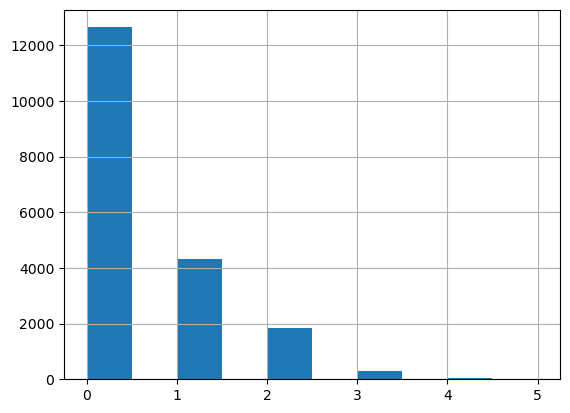

In [71]:
df['children'].hist(bins=10)
plt.show()

Данные дискретны, всего количество детей от 0 до 5, количество наблюдений более 19 тыс. Используем t-тест для проверки гипотез 

In [72]:
# Разделим выборки
group_ch0 = df[df['debt'] == 0]['children']
group_ch1 = df[df['debt'] == 1]['children']

# t-тест для независимых выборок
t_stat1, p_value1 = stats.ttest_ind(group_ch0, group_ch1, equal_var=False)  
print(f"Результат t-теста: t = {t_stat1:.3f}, p_value = {p_value1:.6f}")

# уровень значимсти 
alpha = 0.05
if p_value1 < alpha:
    print("Отвергаем нулевую гипотезу: различия статистически значимы.")
else:
    print("Нет оснований отвергнуть нулевую гипотезу: различия статистически не значимы.")


Результат t-теста: t = -3.468, p_value = 0.000536
Отвергаем нулевую гипотезу: различия статистически значимы.


#### H0: Распределение месячного дохода статистически не различается между клиентами с дефолтом и без дефолта.

#### H1: Распределения статистически значимо различаются.

Для выбора теста проверяем распределение данных и наличие выбросов

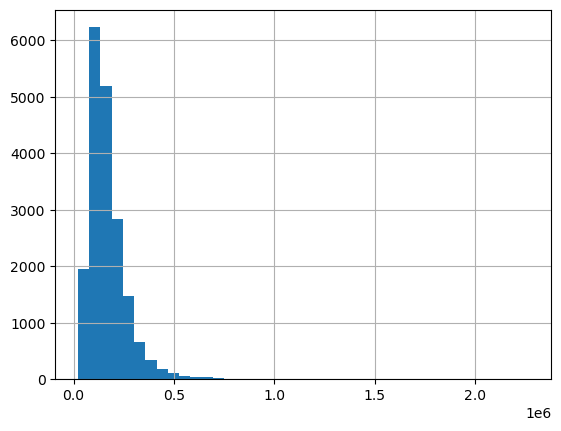

In [73]:
df['total_income'].hist(bins=40)
plt.show()

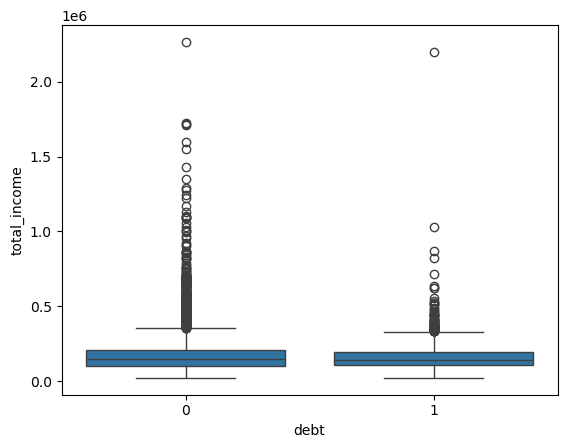

In [74]:
sns.boxplot(x='debt', y='total_income', data=df)
plt.show()

Распределение сильно скошено и много выбросов, используем для проверки гипотезы критерий Манна-Уитни

In [75]:
# Разделяем выборки
group_inc0 = df[df['debt'] == 0]['total_income']
group_inc1 = df[df['debt'] == 1]['total_income']

# Выполняем тест Манна–Уитни 
u_stat2, p_value2 = stats.mannwhitneyu(group_inc0, group_inc1, alternative='two-sided')

# Вывод результатов
print(f"U-статистика: {u_stat2:.4f}")
print(f"p-value: {p_value2:.6f}")


alpha = 0.05
if p_value2 < alpha:
    print("Отвергаем H₀:  распределение дохода статистически значимо не различается у клиентов допустивших дефолт и без дефолта.")
else:
    print("Не отвергаем H₀: распределения дохода статистически значимо различается.")

U-статистика: 13895677.0000
p-value: 0.232808
Не отвергаем H₀: распределения дохода статистически значимо различается.


Доход клиентов статистически значимо различается между группами. При этом медианный доход в двух груаппах отличается всего на 2 тыс.руб., что говорит о небольшом различии. Следовательно, практическая значимость различия для бизнеса оценивается как сомнительная, требуются дополнительные исследования.  